# Lipschitz constant of neural network


In [42]:
import matplotlib.pyplot as plt 
import jax
import numpy as np 
import equinox as eqx
import os
import jax.numpy as jnp
from datasets import init_dataloaders
from solvers.runge_kutta import RK_solver_fixed, RK_tableaux
from forecasters import *
from networks import *
from utils import *

In [2]:
# Lipschitz
# load model 
import json 
from networks import *
import jax
import equinox as eqx
from datasets import *
import os
from forecasters import *
data_integration_method = 'RK4'
dataset_name = 'pendulum'
def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method):
    _, _, test = init_dataloaders(dataset_name, data_integration_method, os.path.join(data_path, dataset_name))
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=test.dataset.dt,
                num_steps=test.dataset.num_steps,
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op

In [94]:
def get_models(model_list, id_list, durations, model_phy_option):
    models = []
    for k, duration in enumerate(durations):
        exp_name = f'{model_phy_option}_aug_{duration}_{id_list[k]}'
        model_name = model_list[k]
        data_path = 'data/lipschitz'
        model_aug_option = True
        dataset_name = 'pendulum'
        models.append(load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, 'RK4')[0])
    return models

# compute jacobienne des modèles
def jacobian(model, x):
    return jax.jit(jax.jacfwd(model))(x)

def jacobian_both(model, x,t):
    return jax.jit(jax.jacfwd(model))(x,t)

def jacobian_max(models):
    jacobians_max_phy = []
    jacobians_max_aug = []
    for model in models:
        q = np.linspace(-15, 15, 10)
        p = np.linspace(-15, 15, 10)
        Q, P = np.meshgrid(q, p)
        jac_norm_aug = []
        jac_norm_phy = []
        for y0 in zip(Q.ravel(), P.ravel()):
            y0 = np.array(y0)
            jac_norm_aug.append(np.linalg.norm(jacobian(model.model_aug, y0)))
            jac_norm_phy.append(np.linalg.norm(jacobian(model.model_phy, y0)))
        jacobians_max_aug.append(np.max(jac_norm_aug))
        jacobians_max_phy.append(np.max(jac_norm_phy))
    return jacobians_max_phy, jacobians_max_aug

def jacobian_mean(models):
    jacobians_mean_phy = []
    jacobians_mean_aug = []
    for model in models:
        q = np.linspace(-15, 15, 10)
        p = np.linspace(-15, 15, 10)
        Q, P = np.meshgrid(q, p)
        jac_norm_aug = []
        jac_norm_phy = []
        for y0 in zip(Q.ravel(), P.ravel()):
            y0 = np.array(y0)
            jac_norm_aug.append(np.linalg.norm(jacobian(model.model_aug, y0)))
            jac_norm_phy.append(np.linalg.norm(jacobian(model.model_phy, y0)))
        jacobians_mean_aug.append(np.mean(jac_norm_aug))
        jacobians_mean_phy.append(np.mean(jac_norm_phy))
    return jacobians_mean_phy, jacobians_mean_aug
    

def jacobian_max_both(models):
    jacobians_max = []
    for model in models:
        q = np.linspace(-15, 15, 10)
        p = np.linspace(-15, 15, 10)
        Q, P = np.meshgrid(q, p)
        jac_norm = []
        for y0 in zip(Q.ravel(), P.ravel()):
            y0 = np.array(y0)
            jac_norm.append(np.linalg.norm(jacobian_both(model.derivative_estimator, y0,0.)))
        jacobians_max.append(np.max(jac_norm))
    return jacobians_max

def Lipschitz_phy(models):
    L_list = [np.sqrt(1+ model.model_phy.omega0_square**2) for model in models]
    return L_list

In [155]:
model_list = ["model_6.485e-05.eqx", "model_1.202e-03.eqx", "model_4.321e-04.eqx", "model_6.669e+00.eqx"]
id_list = ["eiuqzzae", "3eqegq6e","srefavep","aawyc6as"]
models_aph = get_models(model_list, id_list, [5,10,20,40], 'incomplete')
# get validation loss value
val_loss_aph = [0.00006485, 0.001202, 0.0004321, 6.669]

data/lipschitz/incomplete_aug_5_eiuqzzae/model_6.485e-05.eqx
l2
data/lipschitz/incomplete_aug_10_3eqegq6e/model_1.202e-03.eqx
l2
data/lipschitz/incomplete_aug_20_srefavep/model_4.321e-04.eqx
l2
data/lipschitz/incomplete_aug_40_aawyc6as/model_6.669e+00.eqx
l2


In [156]:
model_list = ["model_5.716e-05.eqx","model_4.338e-04.eqx", "model_4.466e-03.eqx", "model_1.557e-01.eqx" ]
id_list = ["r02v0fpj", "sw5xjn9n", "ps3fe9eb", "4lea07pr"]
models_no_Fa = get_models(model_list, id_list, [5,10,20,40], 'incomplete_no_Fa')
val_loss_no_Fa = [0.00005716, 0.0004338, 0.004466, 0.1557]

data/lipschitz/incomplete_no_Fa_aug_5_r02v0fpj/model_5.716e-05.eqx
l2
data/lipschitz/incomplete_no_Fa_aug_10_sw5xjn9n/model_4.338e-04.eqx
l2
data/lipschitz/incomplete_no_Fa_aug_20_ps3fe9eb/model_4.466e-03.eqx
l2
data/lipschitz/incomplete_no_Fa_aug_40_4lea07pr/model_1.557e-01.eqx
l2


In [157]:
model_list = ["model_2.706e-04.eqx","model_4.768e-03.eqx", "model_3.270e-02.eqx", "model_2.942e+00.eqx"  ]
id_list = ["gibieg52", "ws937tr5", "yt8wqw57", "vdb7cfb9"]
models_nn = get_models(model_list, id_list, [5,10,19,40], 'none')
val_loss_nn = [0.0002706, 0.004768, 0.0327, 2.942]

data/lipschitz/none_aug_5_gibieg52/model_2.706e-04.eqx
none
data/lipschitz/none_aug_10_ws937tr5/model_4.768e-03.eqx
none
data/lipschitz/none_aug_19_yt8wqw57/model_3.270e-02.eqx
none
data/lipschitz/none_aug_40_vdb7cfb9/model_2.942e+00.eqx
none


In [158]:
id = "7z3h50vq"
model_name = "model_4.417e+00.eqx"
models_nn = models_nn + get_models([model_name], [id], [60], 'none')

data/lipschitz/none_aug_60_7z3h50vq/model_4.417e+00.eqx
none


## Trajectory loss(T) vs T training

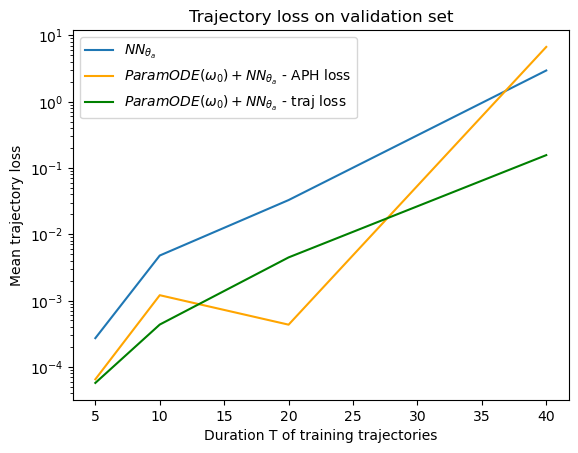

In [163]:
durations = [5,10,20,40]
plt.plot(durations, val_loss_nn, label=r"$NN_{\theta_a}$")
plt.plot(durations, val_loss_aph, color="orange", label=r"$ParamODE(\omega_0)+NN_{\theta_a}$ - APH loss")
plt.plot(durations, val_loss_no_Fa, color="green", label=r"$ParamODE(\omega_0)+NN_{\theta_a}$ - traj loss")
plt.title("Trajectory loss on validation set")
plt.yscale("log")
plt.xlabel("Duration T of training trajectories")
plt.ylabel("Mean trajectory loss")
plt.legend()

Probleme de cette figure: on mesure pas la même quantité pour chaque T puisqu'on regarde une loss sur des trajectoires de longueur différentes. Meilleure figure, inspiration: couleur pour les T d'entrainement et puis courbes des loss(T)

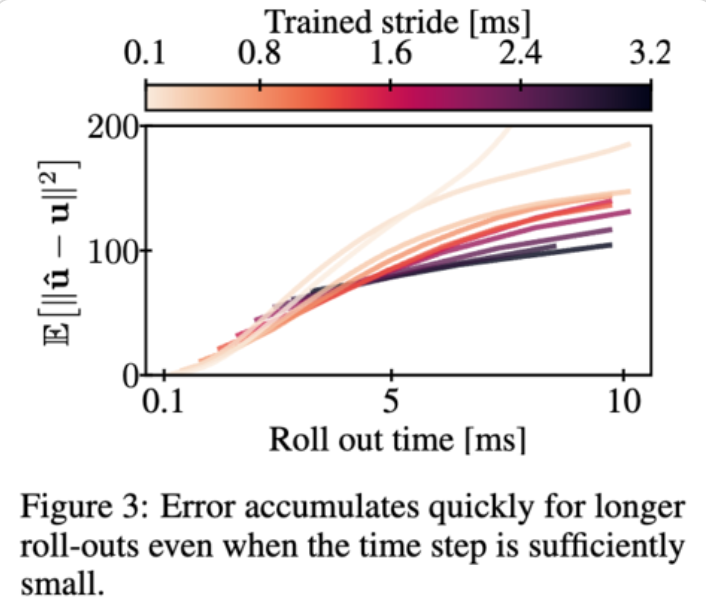

## Influence of model in Lipschitz constant

In [53]:
jacobian_max_phy_aph, jacobian_max_aug_aph = jacobian_max(models_aph)
jacobian_max_phy_no_Fa, jacobian_max_aug_no_Fa = jacobian_max(models_no_Fa)
jacobian_max_phy_nn, jacobian_max_aug_nn = jacobian_max(models_nn)

In [83]:
jacobian_max_phy_nn60, jacobian_max_aug_nn60 = jacobian_max([models_nn[-1]])
jacobian_max_phy_nn, jacobian_max_aug_nn = jacobian_max_phy_nn + jacobian_max_phy_nn60 , jacobian_max_aug_nn + jacobian_max_aug_nn60

In [75]:
jacobian_mean_phy_aph, jacobian_mean_aug_aph = jacobian_mean(models_aph)
jacobian_mean_phy_no_Fa, jacobian_mean_aug_no_Fa = jacobian_mean(models_no_Fa)
jacobian_mean_phy_nn, jacobian_mean_aug_nn = jacobian_mean(models_nn)

In [95]:
jacobian_max_aph =jacobian_max_both(models_aph)
jacobian_max_no_Fa =jacobian_max_both(models_no_Fa)
jacobian_max_nn =jacobian_max_both(models_nn)

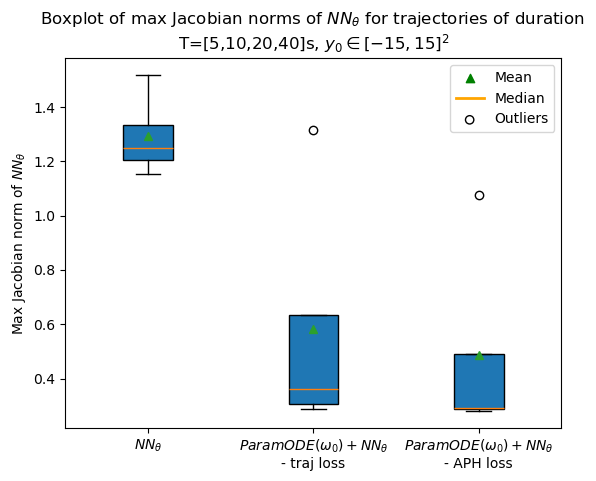

In [84]:
# boxplot jacobians 
losses_traj = [
    jacobian_max_aug_nn[:-1],
    jacobian_max_aug_no_Fa,
    jacobian_max_aug_aph,
]
labels = [r'$NN_{\theta}$', r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- traj loss', r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- APH loss']
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel(r'Max Jacobian norm of $NN_{\theta}$')
#ax.set_yscale('log')

# orientation en biais
bplot = ax.boxplot(losses_traj,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   showmeans=True)  # will be used to label x-ticks
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='upper right')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(r"Boxplot of max Jacobian norms of $NN_{\theta}$ for trajectories of duration "+ "\n"+ r"T=[5,10,20,40]s, $y_0 \in [-15,15]^2$")
plt.show()

## Influence of T training on Lipschitz constant

In [79]:
L_phy_aph = Lipschitz_phy(models_aph)
L_phy_no_Fa = Lipschitz_phy(models_no_Fa)
L_phy_aph, np.sqrt(1+ (2*np.pi/12)**4)

([1.0293205, 1.0309618, 1.0334501, 1.0230867], 1.0368998677183754)

In [80]:
L_phy_no_Fa, np.sqrt(1+ (2*np.pi/12)**4)

([1.0230173, 1.0304633, 1.0218804, 1.0209996], 1.0368998677183754)

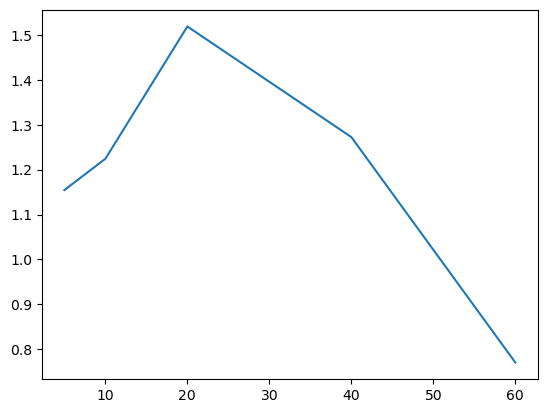

In [85]:
plt.plot([5,10,20,40,60], jacobian_max_aug_nn)

Entrainement explose avce T=60, Nan au bout d'un moment

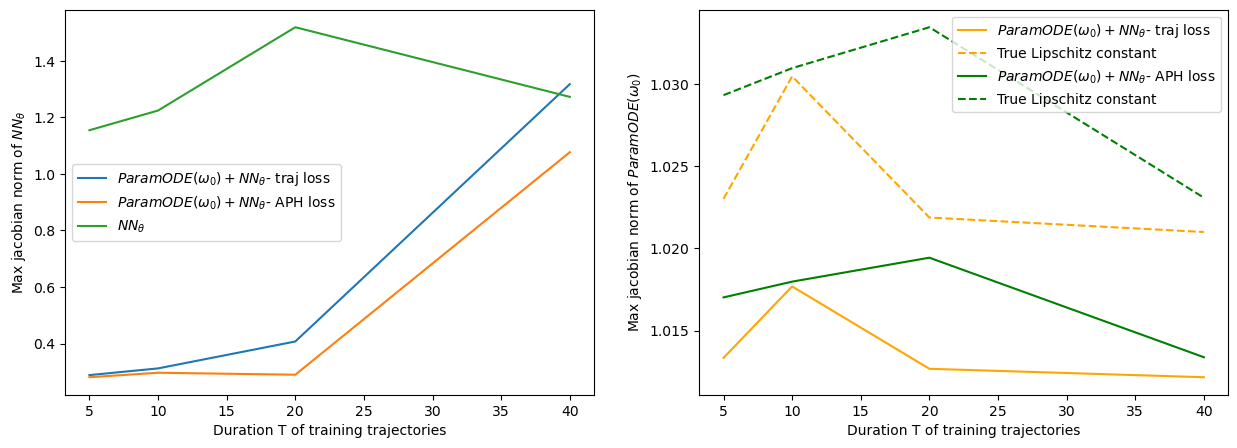

In [87]:
durations = [5,10,20,40]
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(durations, jacobian_max_aug_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss', color='orange')
ax[0].plot(durations, jacobian_max_aug_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss', color='green')
#ax[0].plot(durations, jacobian_max_aug_nn[:-1], label=r'$NN_{\theta} $')
ax[0].legend()
ax[0].set_xlabel('Duration T of training trajectories')
ax[0].set_ylabel(r'Max jacobian norm of $NN_\theta$')
# phy
ax[1].plot(durations, jacobian_max_phy_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss',color='orange')
ax[1].plot(durations, L_phy_no_Fa, label=r'True Lipschitz constant', color='orange', linestyle='--')
ax[1].plot(durations, jacobian_max_phy_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss', color='green')
ax[1].plot(durations, L_phy_aph, label=r'True Lipschitz constant', linestyle='--', color='green')
ax[1].legend()
ax[1].set_xlabel('Duration T of training trajectories')
ax[1].set_ylabel(r'Max jacobian norm of $ParamODE(\omega_0)$')
plt.show()

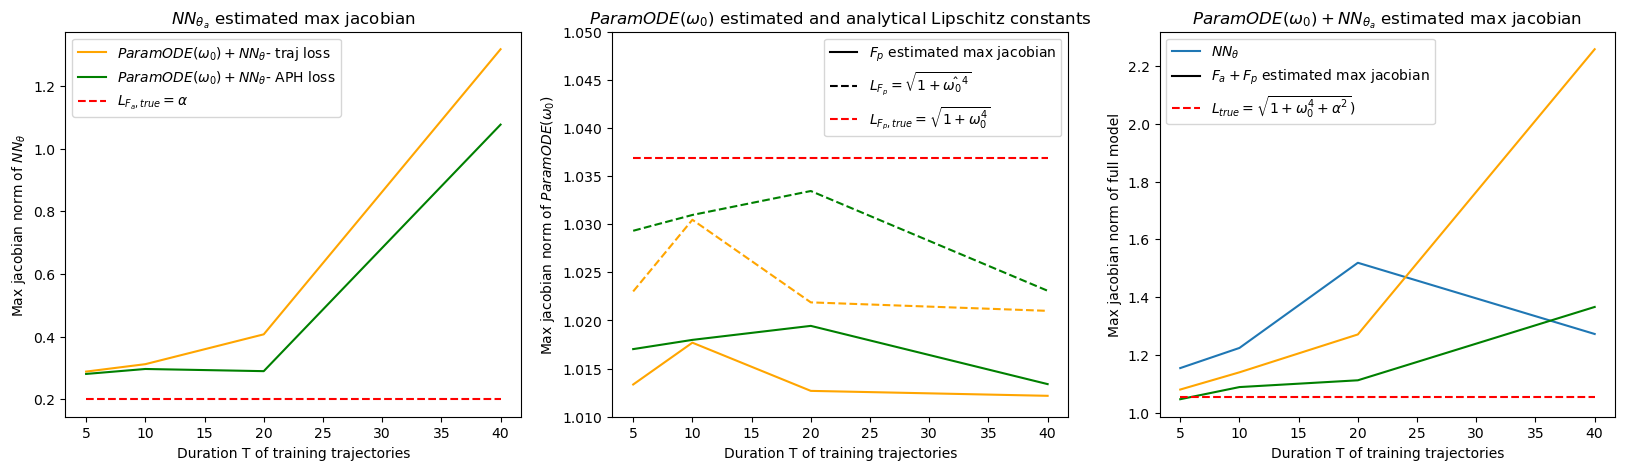

In [154]:
durations = [5,10,20,40]
fig, ax = plt.subplots(1,3, figsize=(20,5))

ax[0].plot(durations, jacobian_max_aug_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss', color='orange')
ax[0].plot(durations, jacobian_max_aug_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss', color='green')

ax[0].hlines(0.2, 5, 40, color='red', linestyle='--', label=r'$L_{F_a, true}=\alpha$')
ax[0].legend()
ax[0].set_xlabel('Duration T of training trajectories')
ax[0].set_ylabel(r'Max jacobian norm of $NN_\theta$')
ax[0].set_title(r'$NN_{\theta_a}$ estimated max jacobian')
# phy
ax[1].plot(durations, jacobian_max_phy_no_Fa,color='orange')
ax[1].plot(durations, L_phy_no_Fa, color='orange', linestyle='--')
ax[1].plot(durations, jacobian_max_phy_aph, color='green')
ax[1].plot(durations, L_phy_aph, linestyle='--', color='green')
# legend in black
ax[1].plot([],[], color='black', label=r'$F_p$ estimated max jacobian')
ax[1].plot([],[], color='black', linestyle='--', label=r'$L_{F_p}=\sqrt{1+\hat{\omega_0}^4}$')
ax[1].hlines(np.sqrt(1+ (2*np.pi/12)**4), 5, 40, color='red', linestyle='--', label=r'$L_{F_p, true}=\sqrt{1+\omega_0^4}$')
ax[1].legend()
ax[1].set_ylim(1.01,1.05)
ax[1].set_xlabel('Duration T of training trajectories')
ax[1].set_ylabel(r'Max jacobian norm of $ParamODE(\omega_0)$')
ax[1].set_title(r"$ParamODE(\omega_0)$ estimated and analytical Lipschitz constants")
# full 
ax[2].plot(durations, jacobian_max_aug_nn[:-1], label=r'$NN_{\theta} $')
ax[2].plot(durations, jacobian_max_aph, color='green')
ax[2].plot(durations, jacobian_max_no_Fa, color='orange')
ax[2].plot([],[], color='black', label=r'$F_a+F_p$ estimated max jacobian')
ax[2].hlines(L_true, 5, 40, color='red', linestyle='--', label=r'$L_{true}=\sqrt{1+\omega_0^4+ \alpha^2 })$')
ax[2].set_title(r'$ParamODE(\omega_0)+NN_{\theta_a}$ estimated max jacobian')
ax[2].legend()
ax[2].set_xlabel('Duration T of training trajectories')
ax[2].set_ylabel(r'Max jacobian norm of full model')
plt.show()

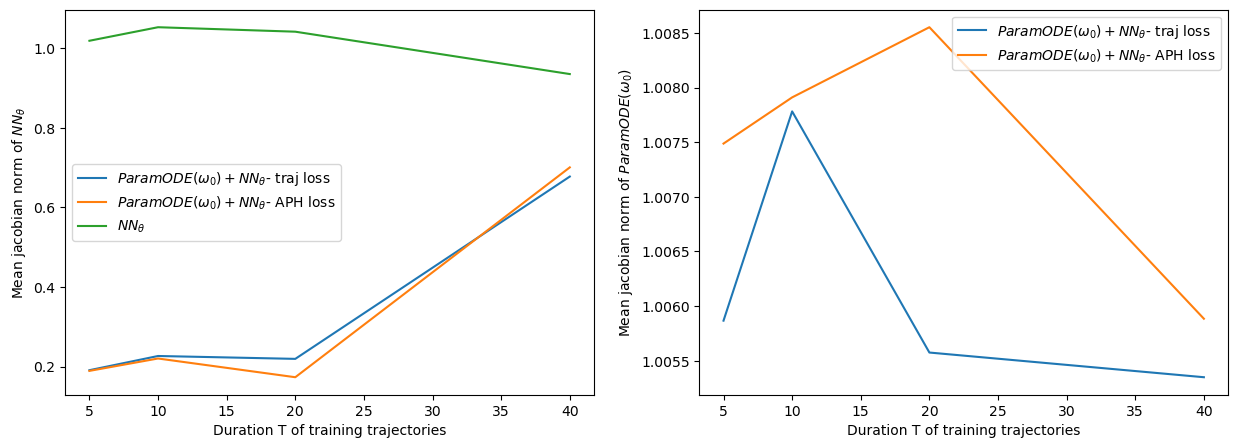

In [77]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(durations, jacobian_mean_aug_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss')
ax[0].plot(durations, jacobian_mean_aug_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss')
ax[0].plot(durations, jacobian_mean_aug_nn, label=r'$NN_{\theta} $')
ax[0].legend()
ax[0].set_xlabel('Duration T of training trajectories')
ax[0].set_ylabel(r'Mean jacobian norm of $NN_\theta$')
# phy
ax[1].plot(durations, jacobian_mean_phy_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss')
ax[1].plot(durations, jacobian_mean_phy_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss')
ax[1].legend()
ax[1].set_xlabel('Duration T of training trajectories')
ax[1].set_ylabel(r'Mean jacobian norm of $ParamODE(\omega_0)$')
plt.show()

Pas concluant séparement, peut être mieux si on considère le réseau entier, par rapport à la vraie constante qu'on doit trouver

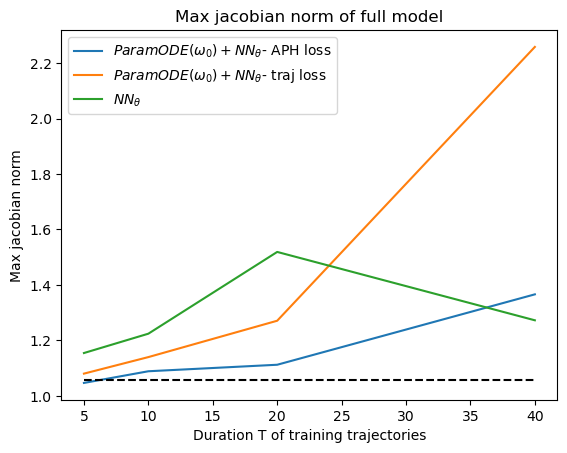

In [99]:
plt.plot(durations, jacobian_max_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss')
plt.plot(durations, jacobian_max_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss')
plt.plot(durations, jacobian_max_nn[:-1], label=r'$NN_{\theta} $')
plt.legend()
plt.xlabel('Duration T of training trajectories')
plt.ylabel(r'Max jacobian norm')
plt.title("Max jacobian norm of full model")
plt.hlines(np.sqrt(1+ (2*np.pi/12)**4+ 0.2**2), 5, 40, color='black', linestyle='--', label='True Lipschitz constant')
plt.show()


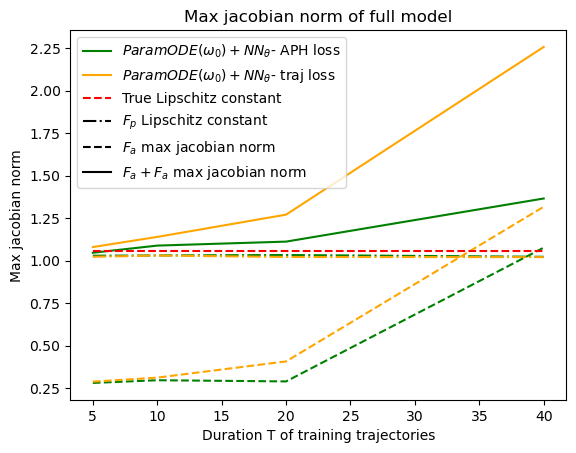

In [113]:
#plt.plot(durations, jacobian_max_phy_aph, color="green", linestyle='dashdot')
#plt.plot(durations, jacobian_max_phy_no_Fa, color="orange", linestyle='dashdot')
plt.plot(durations, L_phy_aph, color="green", linestyle="dashdot")
plt.plot(durations, L_phy_no_Fa, color="orange", linestyle="dashdot")
plt.plot(durations, jacobian_max_aug_aph, color="green", linestyle='--')
plt.plot(durations, jacobian_max_aug_no_Fa, color="orange",linestyle='--')
plt.plot(durations, jacobian_max_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss', color="green", )
plt.plot(durations, jacobian_max_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss', color="orange", )
#plt.plot(durations, jacobian_max_nn[:-1], label=r'$NN_{\theta} $')
plt.legend()
plt.xlabel('Duration T of training trajectories')
plt.ylabel(r'Max jacobian norm')
plt.title("Max jacobian norm of full model")
plt.hlines(np.sqrt(1+ (2*np.pi/12)**4+ 0.2**2), 5, 40, color='red', linestyle='--', label='True Lipschitz constant')
# legend of linestyles
plt.plot([], [], color='black', linestyle='dashdot', label=r'$F_p$ Lipschitz constant')
plt.plot([], [], color='black', linestyle='--', label=r'$F_a$ max jacobian norm')
plt.plot([], [], color='black', linestyle='-', label=r'$F_a+F_a$ max jacobian norm')
plt.legend()
plt.show()


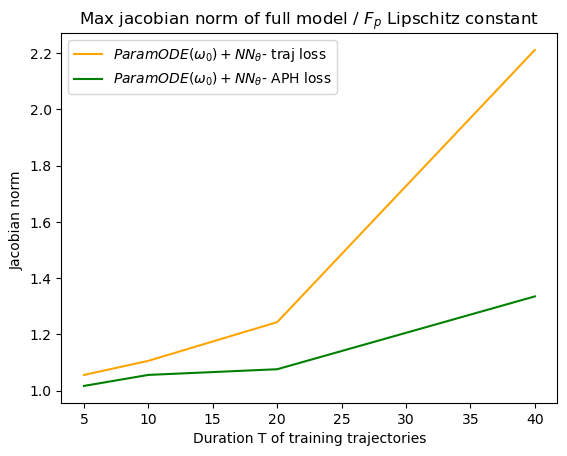

In [126]:
#plt.plot(durations, jacobian_max_phy_aph, color="green", linestyle='dashdot')
#plt.plot(durations, jacobian_max_phy_no_Fa, color="orange", linestyle='dashdot')
L_true = np.sqrt(1+ (2*np.pi/12)**4+ 0.2**2)
#plt.plot(durations, np.sqrt(np.array(jacobian_max_aph)**2-np.array(L_phy_aph)**2)/np.array(L_phy_aph), color="green", linestyle="dashdot")
#plt.plot(durations, np.sqrt(np.array(jacobian_max_no_Fa)**2-np.array(L_phy_no_Fa)**2)/np.array(L_phy_no_Fa), color="orange", linestyle="dashdot")
plt.plot(durations, np.array(jacobian_max_no_Fa)/np.array(L_phy_no_Fa), color="orange", label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss') #, linestyle="dashdot")
plt.plot(durations, np.array(jacobian_max_aph)/np.array(L_phy_aph), color="green", label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss') #, linestyle="dashdot")
#plt.plot(durations, np.array(jacobian_max_aph)-L_true/L_true, color="green")
#plt.plot(durations, np.array(jacobian_max_no_Fa)-L_true/L_true, color="orange")
#plt.plot(durations, jacobian_max_aug_aph, color="green", linestyle='--')
#plt.plot(durations, jacobian_max_aug_no_Fa, color="orange",linestyle='--')
#plt.plot(durations, jacobian_max_aph, label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss', color="green", )
#plt.plot(durations, jacobian_max_no_Fa, label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss', color="orange", )
#plt.plot(durations, jacobian_max_nn[:-1], label=r'$NN_{\theta} $')
plt.legend()
plt.xlabel('Duration T of training trajectories')
plt.ylabel(r'Jacobian norm ')
plt.title(r"Max jacobian norm of full model / $F_p$ Lipschitz constant")
#plt.hlines(np.sqrt(1+ (2*np.pi/12)**4+ 0.2**2), 5, 40, color='red', linestyle='--', label='True Lipschitz constant')
# legend of linestyles
#plt.plot([], [], color='black', linestyle='dashdot', label=r'$F_p$ Lipschitz constant')
#plt.plot([], [], color='black', linestyle='--', label=r'$F_a$ max jacobian norm')
#plt.plot([], [], color='black', linestyle='-', label=r'$F_a+F_a$ max jacobian norm')
plt.legend()
plt.show()


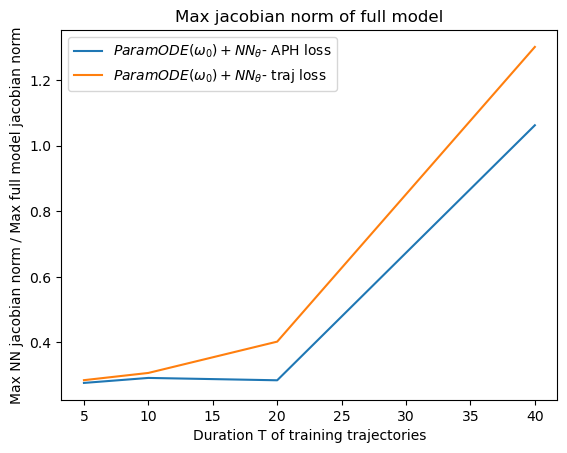

In [103]:
plt.plot(durations, np.array(jacobian_max_aug_aph)/np.array(jacobian_max_phy_aph), label=r'$ParamODE(\omega_0)+NN_\theta$- APH loss')
plt.plot(durations, np.array(jacobian_max_aug_no_Fa)/np.array(jacobian_max_phy_no_Fa), label=r'$ParamODE(\omega_0)+NN_\theta$- traj loss')
#plt.plot(durations, np.array(jacobian_max_aug_nn[:-1])/np.array(jacobian_max_nn[:-1]), label=r'$NN_{\theta} $')
plt.legend()
plt.xlabel('Duration T of training trajectories')
plt.ylabel(r'Max NN jacobian norm / Max full model jacobian norm')
plt.title("Max jacobian norm of full model")
#plt.hlines(np.sqrt(1+ (2*np.pi/12)**4+ 0.2**2), 5, 40, color='black', linestyle='--', label='True Lipschitz constant')
plt.show()


# Estimating Lipschitz constant: max jacobian method
Illustrate our method for different $\omega_0$

In [186]:
def compute_jacobian_max(w0):
    def model(y):
        return jnp.array([y[1], -w0**2*jnp.sin(y[0])])
    q = np.linspace(-15, 15, 15)
    p = np.linspace(-15, 15, 15)
    Q, P = np.meshgrid(q, p)
    jac_norm_phy = []
    for y0 in zip(Q.ravel(), P.ravel()):
        y0 = np.array(y0)
        jac_norm_phy.append(np.linalg.norm(jacobian(model, y0)))
    return np.max(jac_norm_phy)

In [172]:
T0_list = np.arange(1,20)
w0_list = np.array([2*np.pi/t0 for t0 in T0_list])
L_list = np.sqrt(1+ w0_list**4)
L_estimated = []
for w0 in w0_list:
    L_estimated.append(compute_jacobian_max(w0))
L_estimated

[30.007942,
 7.564211,
 3.479174,
 2.1245189,
 1.5617819,
 1.3015531,
 1.1724445,
 1.1043545,
 1.0663463,
 1.0440056,
 1.0302598,
 1.0214585,
 1.0156245,
 1.0116394,
 1.0088446,
 1.006839,
 1.0053704,
 1.0042751,
 1.003445]

In [187]:
L_estimated_225 = []
for w0 in w0_list:
    L_estimated_225.append(compute_jacobian_max(w0))

In [175]:
L_list-L_estimated

array([9.48313852e+00, 2.35592474e+00, 1.01985955e+00, 5.37823742e-01,
       3.07355011e-01, 1.82556492e-01, 1.11737562e-01, 7.05941202e-02,
       4.61045819e-02, 3.11011277e-02, 2.16197803e-02, 1.54413611e-02,
       1.12975813e-02, 8.44407968e-03, 6.43174396e-03, 4.98185450e-03,
       3.91675705e-03, 3.12090791e-03, 2.51683929e-03])

In [190]:
L_list - L_estimated_225

array([-5.16394138e-07,  1.37820329e-07, -6.81227075e-09,  6.47478586e-08,
       -3.49881204e-08, -1.78933199e-08,  7.20485664e-08,  4.78286886e-08,
        3.15857260e-08,  2.01215227e-08, -1.64127685e-08, -5.65598839e-08,
       -2.26404073e-09,  8.86759777e-09,  4.51613398e-08, -2.09155675e-08,
        1.66364231e-08,  8.70792549e-09, -2.64375202e-08])

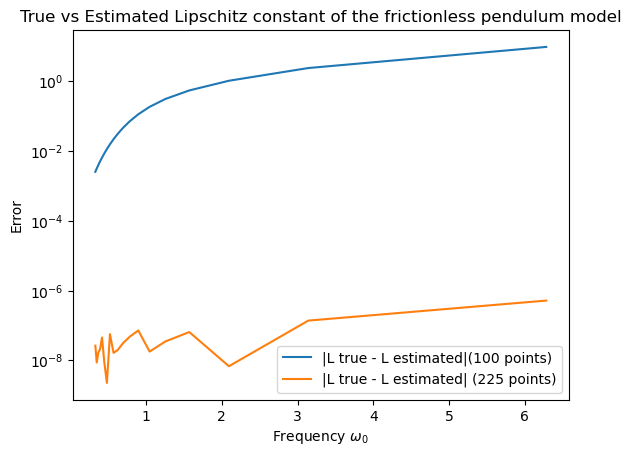

In [194]:
#plt.plot(w0_list, L_list, label='True Lipschitz constant')
#plt.plot(w0_list, L_estimated, label='Estimated Lipschitz constant (100 points)')
#plt.plot(w0_list, L_estimated_225, label='Estimated Lipschitz constant (225 points)')
plt.plot(w0_list, np.abs(L_list-L_estimated), label='|L true - L estimated|(100 points)')
plt.plot(w0_list, np.abs(L_list - L_estimated_225), label='|L true - L estimated| (225 points)')
plt.xlabel(r"Frequency $\omega_0$")
plt.ylabel(r"Error")
plt.yscale('log')
plt.title("True vs Estimated Lipschitz constant of the frictionless pendulum model")
#plt.title("Error in the estimation of the Lipschitz constant"+"\n"+" of the frictionless pendulum model")
plt.legend()
plt.show()


With 100 points, L_estimated is a lower bound of L, but with 225 points the error is much smaller but not a lower bound (sometimes overestimates L).

In [183]:
def model(y):
    return jnp.array([y[1], -jnp.sin(y[0])])

jax.jacfwd(model)(np.array([0.,0.]))

Array([[ 0.,  1.],
       [-1., -0.]], dtype=float32)